# Fashion Sales — Time Series Analysis & Forecasting
## Following CRISP-DM Framework (Lec13: Introduction to Time Series Modeling)
**ITCS 227 – Introduction to Data Science | Mahidol University 2026**

---

### Research Questions
1. What are the long-term sales trends and seasonal patterns for each fashion category (2018–2025)?
2. Is the sales time series stationary, or does it require detrending?
3. Can a Seasonal Linear Regression model outperform a Naive Seasonal baseline?
4. What are the predicted fashion sales for 2026?

### CRISP-DM Steps Applied
| Step | Action |
|---|---|
| 1. Business Understanding | Define objective: forecast monthly fashion sales by category |
| 2. Data Understanding / Preparation | Load data, explore time intervals, check stationarity, ACF/PACF, feature engineering |
| 3. Modeling | Naive Seasonal baseline (K=12) + Seasonal Linear Regression |
| 4. Evaluation | MAE, RMSE, R2, MAPE, MASE (compared against Naive Seasonal) |

---
## Step 1 — Business Understanding

**Objective:** Forecast monthly sales counts per fashion category to support inventory and marketing decisions.

**Crucial Decision:** Accurately predicting which categories peak in which months.
False Negatives (missing a peak) cause stockouts — more costly than overstocking.

**Positive (P):** Sales above seasonal average → Stock up  
**Negative (N):** Sales below seasonal average → Reduce stock

---
## Step 2 — Data Understanding & Preparation

### 2A. Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size']         = 11

COLORS = ['#E8A0BF','#BA90C6','#C0DBEA','#8EC5FC','#F5CBA7','#A9DFBF','#F9E79F','#D5DBDB']
print('Libraries imported successfully.')

Libraries imported successfully.


### 2B. Load Dataset & Build Monthly Time Series

In [17]:
df = pd.read_excel('fashion_new_data2.xlsx')

df['date'] = pd.to_datetime(
    df['year_of_sale'].astype(str) + '-' +
    df['month_of_sale'].astype(str).str.zfill(2) + '-01'
)

monthly = df.groupby(['date', 'category'])['sales_count'].sum().unstack(fill_value=0)
total   = monthly.sum(axis=1)

print(f'Time range  : {monthly.index[0].strftime("%b %Y")} to {monthly.index[-1].strftime("%b %Y")}')
print(f'Observations: {len(monthly)} monthly data points')
print(f'Categories  : {list(monthly.columns)}')
print(f'Missing values: {monthly.isnull().sum().sum()}')
monthly.head()

Time range  : Jan 2018 to Dec 2025
Observations: 96 monthly data points
Categories  : ['Blouse', 'Dress', 'Jacket', 'Jeans', 'Shirt', 'Shoes', 'Shorts', 'Skirt']
Missing values: 0


category,Blouse,Dress,Jacket,Jeans,Shirt,Shoes,Shorts,Skirt
date,,,,,,,,
2018-01-01,100,354,296,335,910,333,435,0
2018-02-01,0,0,62,1148,0,0,998,1054
2018-03-01,78,442,0,177,142,803,1020,78
2018-04-01,422,466,457,547,360,160,138,255
2018-05-01,549,560,1266,484,257,0,170,0


### 2C. Explore Time Intervals — Raw Time Series Plot

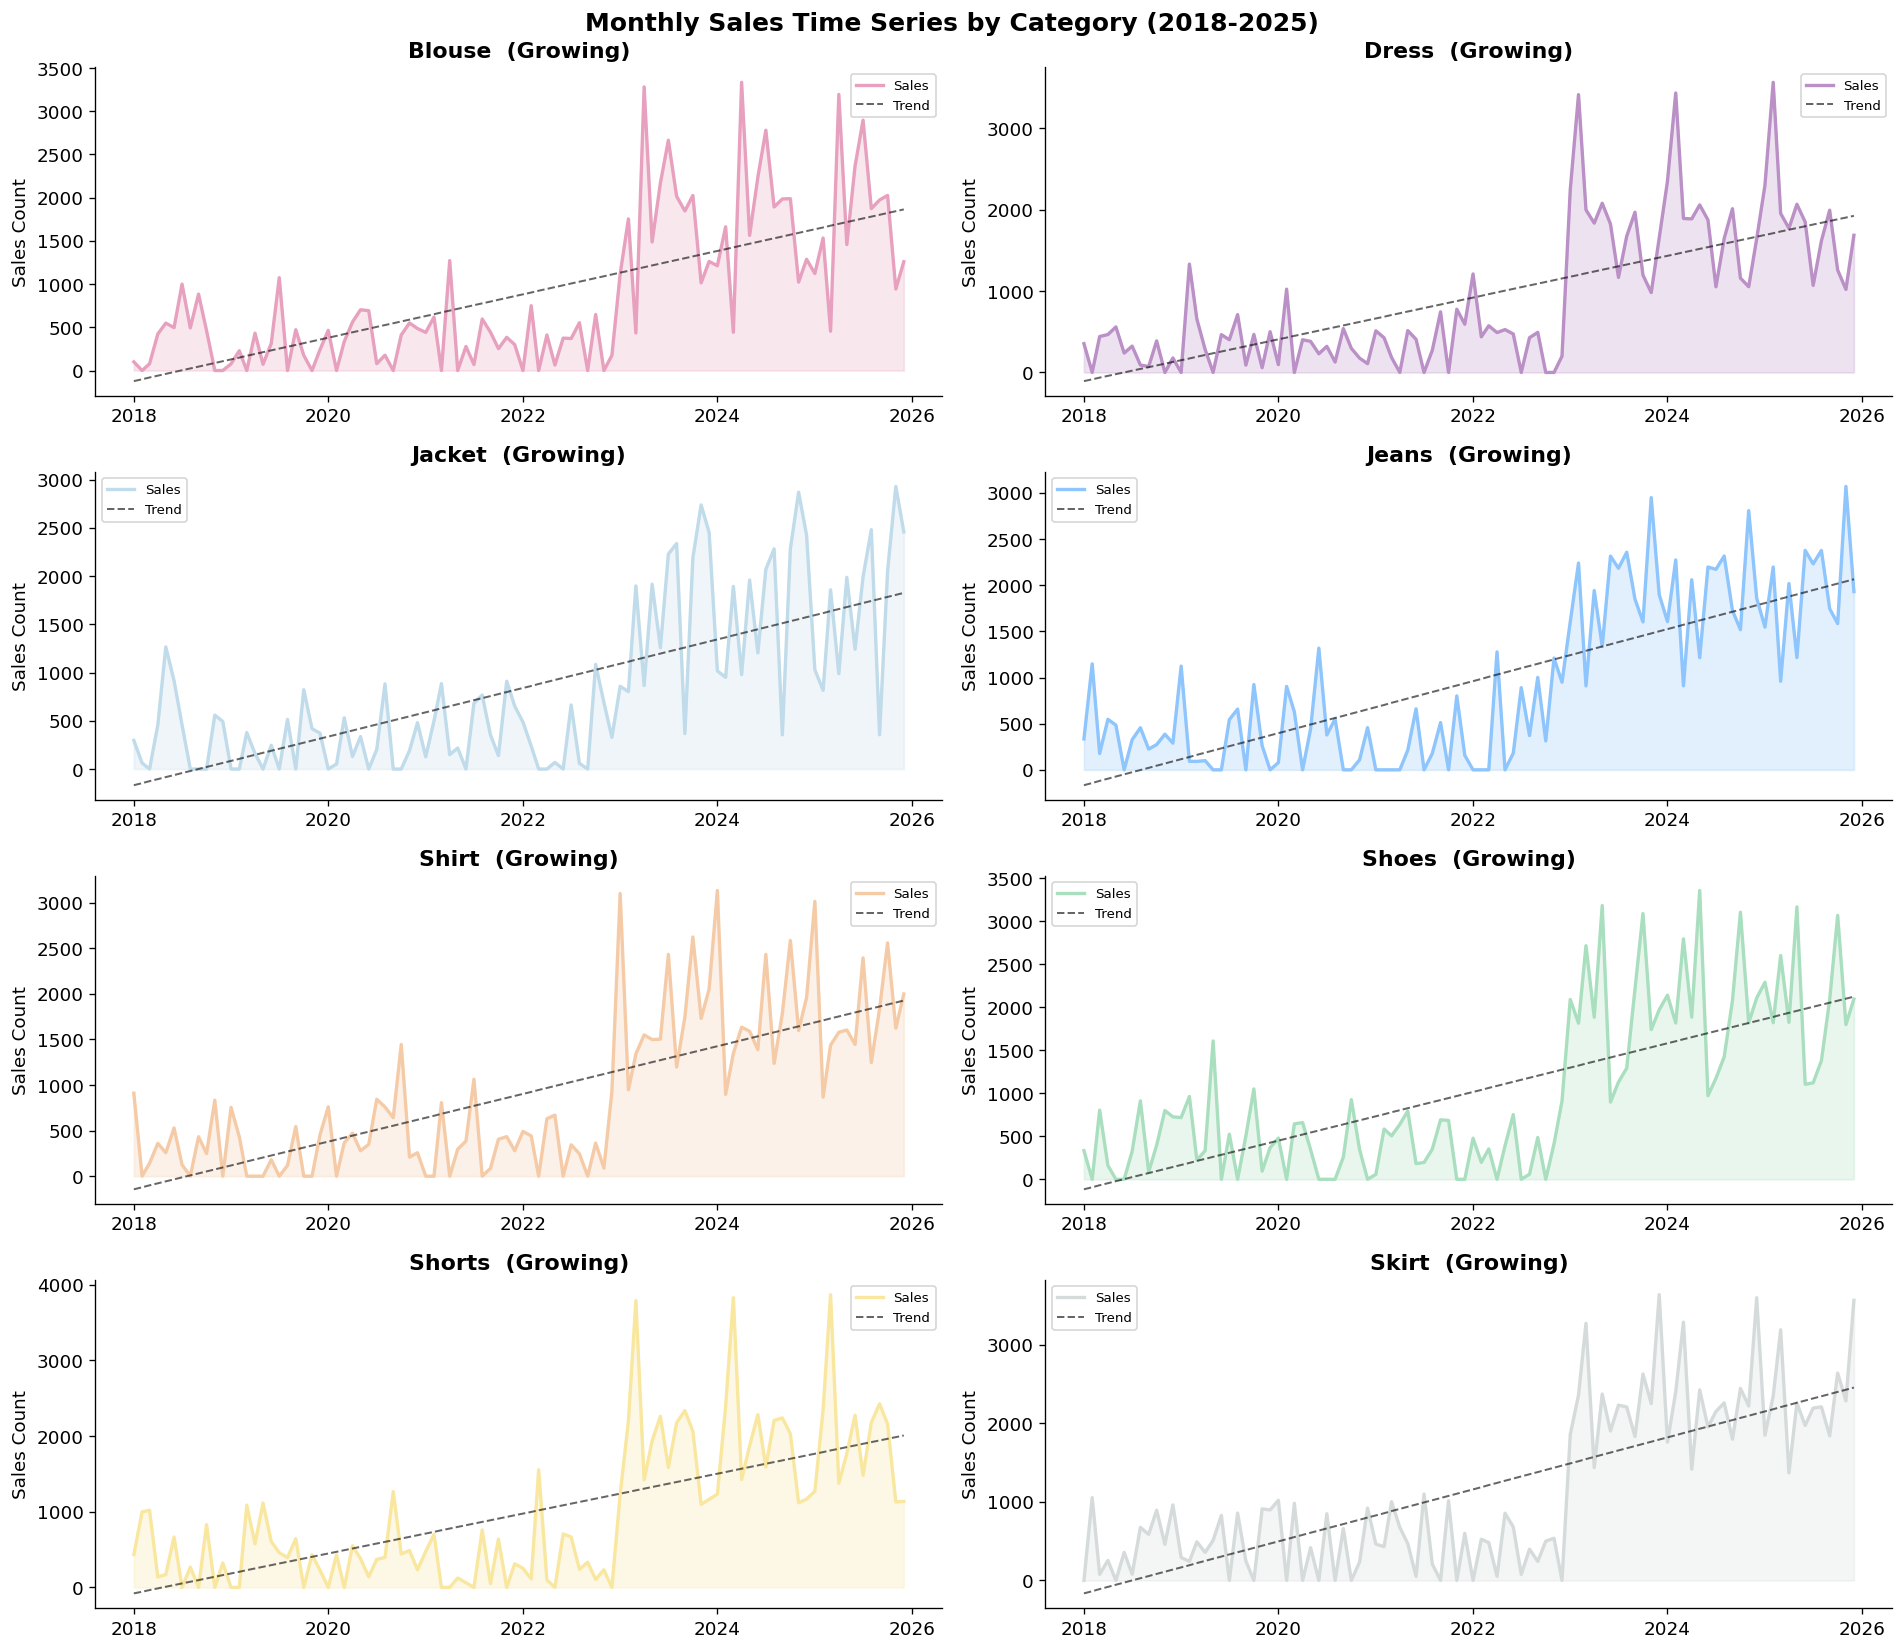

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Monthly Sales Time Series by Category (2018-2025)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (cat, color) in enumerate(zip(monthly.columns, COLORS)):
    ax = axes[i]
    ax.fill_between(monthly.index, monthly[cat], alpha=0.25, color=color)
    ax.plot(monthly.index, monthly[cat], color=color, linewidth=2, label='Sales')
    x = np.arange(len(monthly))
    z = np.polyfit(x, monthly[cat], 1)
    ax.plot(monthly.index, np.poly1d(z)(x), 'k--', linewidth=1.2, alpha=0.6, label='Trend')
    direction = 'Growing' if z[0] > 0 else 'Declining'
    ax.set_title(f'{cat}  ({direction})', fontweight='bold')
    ax.set_ylabel('Sales Count')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.tight_layout()
plt.show()

### 2D. STL Decomposition — Trend, Seasonality, Residual
> From Lec13: a time series = **Trend + Seasonality + Residual Noise**.
> Classical autoregressive algorithms (ARIMA) require this decomposition (STL) to isolate components.

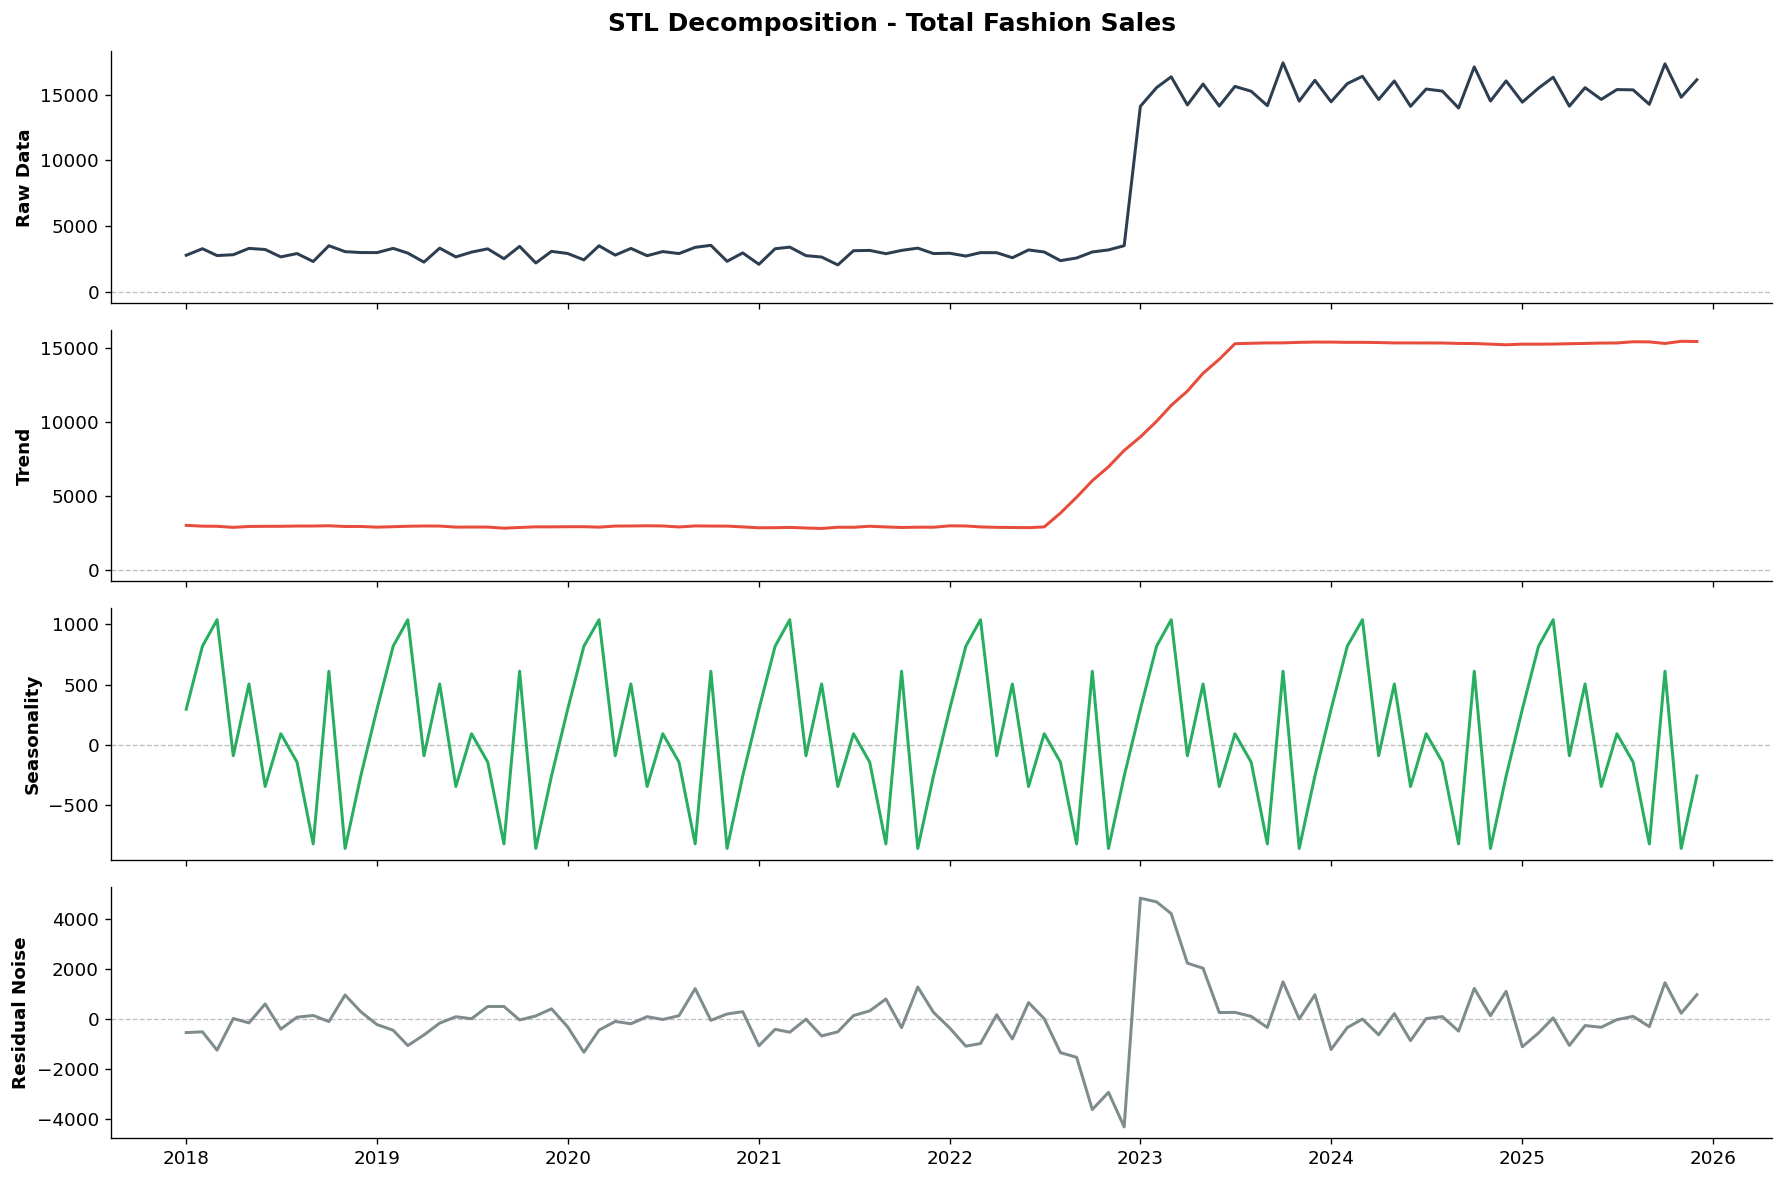

STL Interpretation:
  Trend    : Overall direction of total sales over 2018-2025
  Seasonal : Repeating monthly patterns (period = 12 months)
  Residual : Unexplained noise after removing trend and seasonality


In [19]:
def manual_stl(series, period=12):
    """Manual STL decomposition: rolling mean trend + monthly seasonal index."""
    df_stl = pd.DataFrame({'raw': series})
    df_stl['trend']     = df_stl['raw'].rolling(period, center=True, min_periods=1).mean()
    df_stl['detrended'] = df_stl['raw'] - df_stl['trend']
    df_stl['month']     = series.index.month
    seasonal_idx        = df_stl.groupby('month')['detrended'].mean()
    df_stl['seasonal']  = df_stl['month'].map(seasonal_idx)
    df_stl['residual']  = df_stl['raw'] - df_stl['trend'] - df_stl['seasonal']
    return df_stl

stl = manual_stl(total)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
fig.suptitle('STL Decomposition - Total Fashion Sales', fontsize=15, fontweight='bold')

components = [
    ('raw',      'Raw Data',        '#2C3E50'),
    ('trend',    'Trend',           '#E74C3C'),
    ('seasonal', 'Seasonality',     '#27AE60'),
    ('residual', 'Residual Noise',  '#7F8C8D'),
]
for ax, (col, label, color) in zip(axes, components):
    ax.plot(stl.index, stl[col], color=color, linewidth=1.8)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel(label, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

print('STL Interpretation:')
print('  Trend    : Overall direction of total sales over 2018-2025')
print('  Seasonal : Repeating monthly patterns (period = 12 months)')
print('  Residual : Unexplained noise after removing trend and seasonality')

### 2E. Stationarity Check
> From Lec13: A stationary series has **constant mean and variance** over time.
> Non-stationary data must be detrended before fitting classical models (ARIMA).
> We apply **1st-order differencing** as taught in Lec13 (Transforms for Stationarity).

--- Original Total Sales ---
  Mean  : 1st half = 2924.7  |  2nd half = 12199.7
  StdDev: 1st half = 390.0  |  2nd half = 5489.3
  Variance ratio (2nd/1st) = 198.06
  Result: NON-STATIONARY (variance ratio > 1.5)

--- After 1st-Order Differencing ---
  Mean  : 1st half = 2.8  |  2nd half = 275.7
  StdDev: 1st half = 637.4  |  2nd half = 2144.0
  Variance ratio (2nd/1st) = 11.31
  Result: NON-STATIONARY (variance ratio > 1.5)



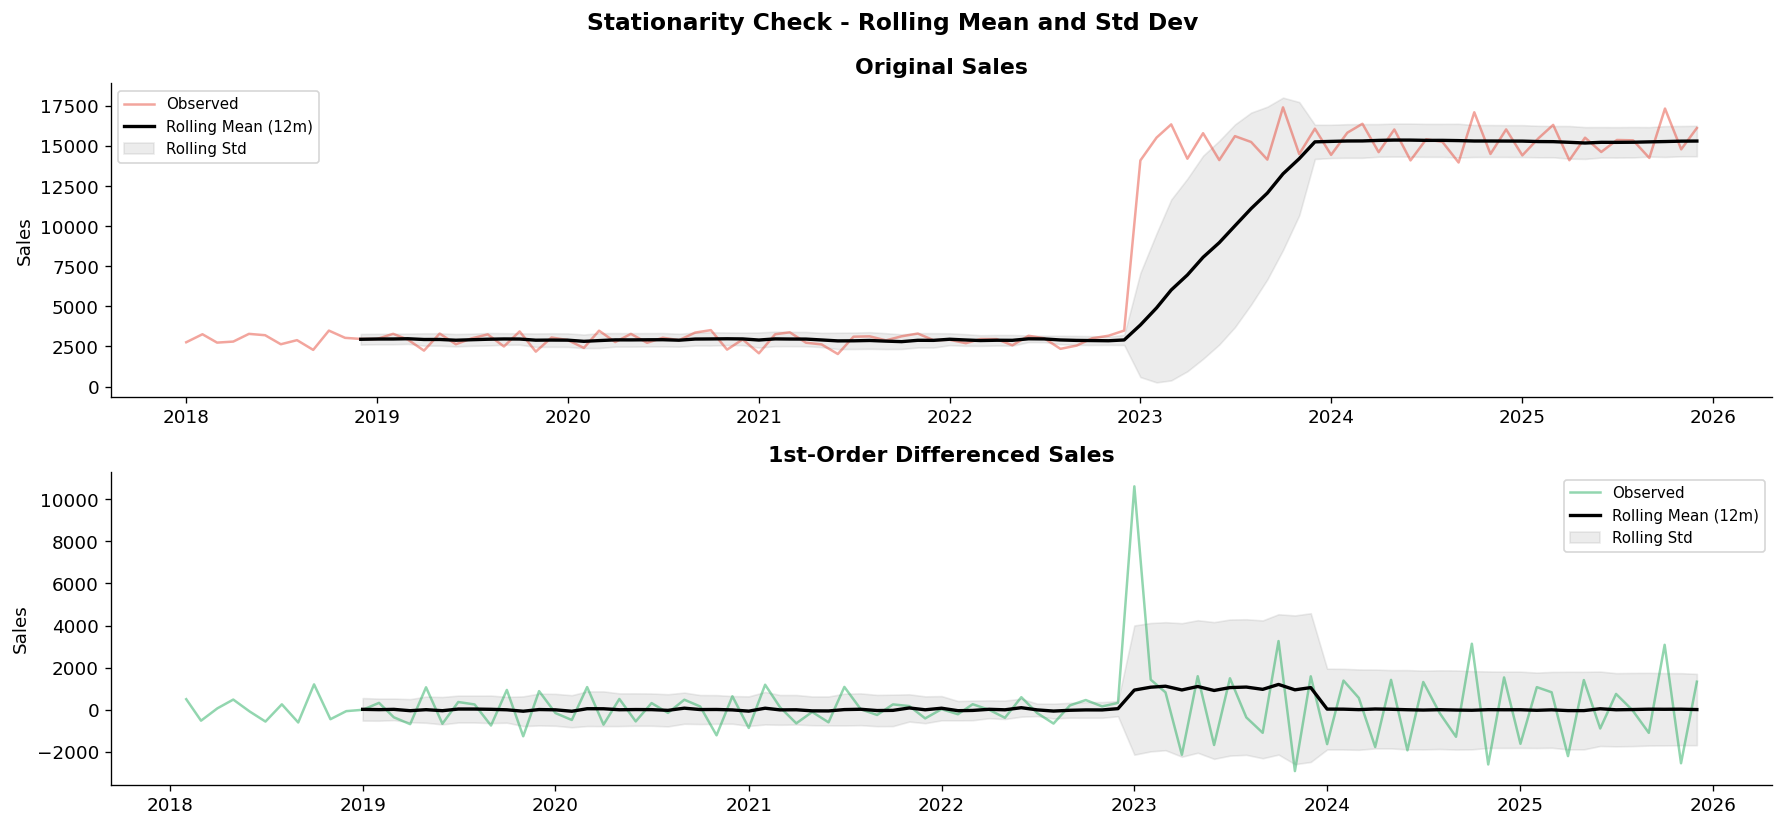

In [20]:
def check_stationarity(series, name='Series'):
    first_half  = series[:len(series)//2]
    second_half = series[len(series)//2:]
    var_ratio   = second_half.var() / (first_half.var() + 1e-9)
    print(f'--- {name} ---')
    print(f'  Mean  : 1st half = {first_half.mean():.1f}  |  2nd half = {second_half.mean():.1f}')
    print(f'  StdDev: 1st half = {first_half.std():.1f}  |  2nd half = {second_half.std():.1f}')
    print(f'  Variance ratio (2nd/1st) = {var_ratio:.2f}')
    label = 'NON-STATIONARY (variance ratio > 1.5)' if var_ratio > 1.5 else 'Likely STATIONARY'
    print(f'  Result: {label}')
    print()

check_stationarity(total, 'Original Total Sales')

total_diff = total.diff().dropna()
check_stationarity(total_diff, 'After 1st-Order Differencing')

# Visualize rolling statistics
fig, axes = plt.subplots(2, 1, figsize=(15, 7))
fig.suptitle('Stationarity Check - Rolling Mean and Std Dev', fontsize=14, fontweight='bold')

for ax, (series, label, color) in zip(axes, [
    (total,      'Original Sales',               '#E74C3C'),
    (total_diff, '1st-Order Differenced Sales',  '#27AE60'),
]):
    roll_mean = series.rolling(12).mean()
    roll_std  = series.rolling(12).std()
    ax.plot(series.index, series,    color=color,   linewidth=1.5, alpha=0.5, label='Observed')
    ax.plot(series.index, roll_mean, color='black', linewidth=2,   label='Rolling Mean (12m)')
    ax.fill_between(series.index, roll_mean-roll_std, roll_mean+roll_std,
                    alpha=0.15, color='gray', label='Rolling Std')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Sales')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.show()

### 2F. ACF & PACF — Lag Correlation Plots
> From Lec13:
> - **ACF** — measures correlation between series and its lagged values (identifies MA order)
> - **PACF** — removes intermediate lag influence (identifies AR order)
> - Significant correlations lie **outside the 95% confidence band** (blue region)

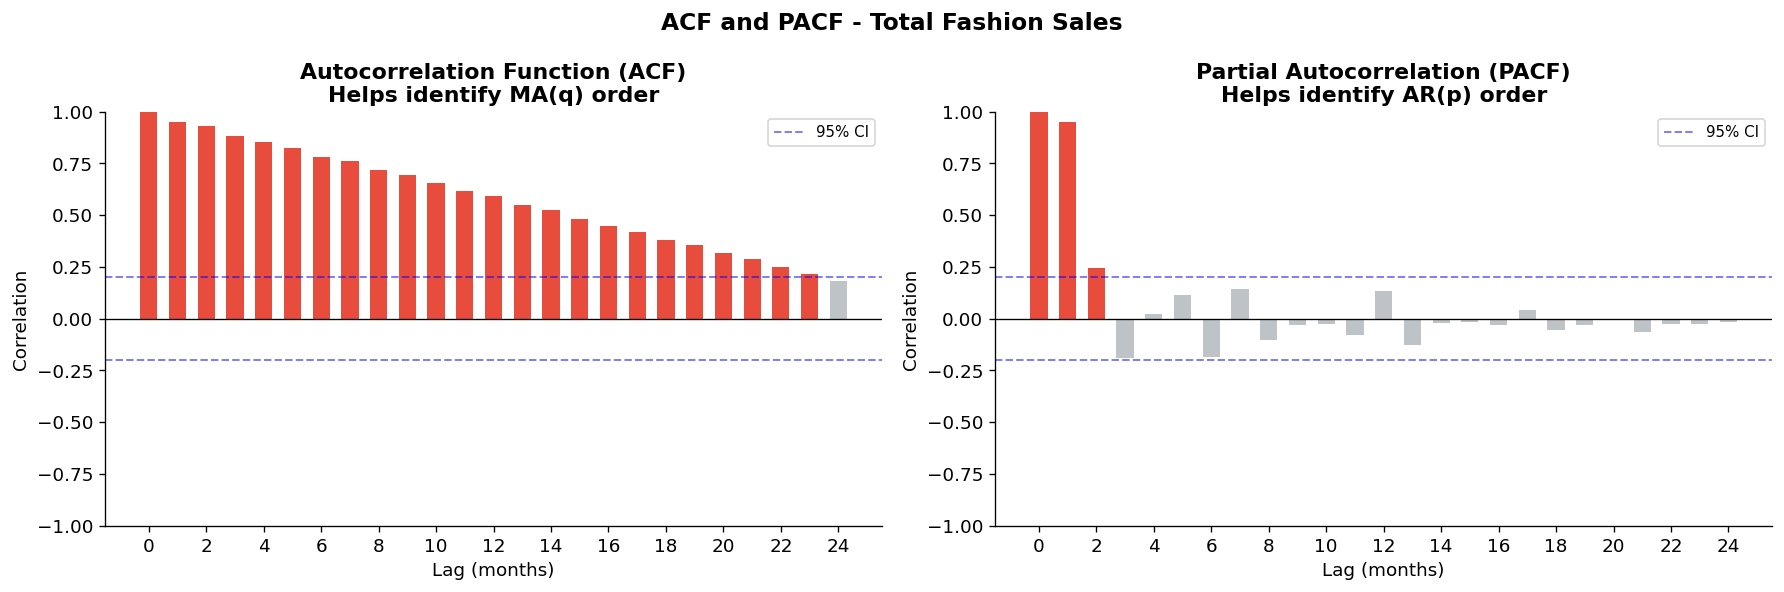

Significant ACF lags (outside 95% CI): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
ACF at lag-12 = 0.592
Strong 12-month seasonality confirmed.


In [21]:
def compute_acf(series, n_lags=24):
    s   = series - series.mean()
    n   = len(s)
    var = np.var(s)
    acf_vals = [1.0]
    for lag in range(1, n_lags+1):
        cov = np.sum(s.values[lag:] * s.values[:-lag]) / n
        acf_vals.append(cov / (var + 1e-9))
    return np.array(acf_vals)

def compute_pacf(series, n_lags=24):
    acf_v = compute_acf(series, n_lags)
    pacf_v = [1.0]
    for k in range(1, n_lags+1):
        r = acf_v[1:k+1]
        R = np.array([[acf_v[abs(i-j)] for j in range(k)] for i in range(k)])
        try:
            phi = np.linalg.solve(R, r)
            pacf_v.append(phi[-1])
        except:
            pacf_v.append(0)
    return np.array(pacf_v)

N_LAGS    = 24
acf_vals  = compute_acf(total, N_LAGS)
pacf_vals = compute_pacf(total, N_LAGS)
ci        = 1.96 / np.sqrt(len(total))
lags      = np.arange(N_LAGS+1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ACF and PACF - Total Fashion Sales', fontsize=14, fontweight='bold')

for ax, vals, title in [
    (axes[0], acf_vals,  'Autocorrelation Function (ACF)\nHelps identify MA(q) order'),
    (axes[1], pacf_vals, 'Partial Autocorrelation (PACF)\nHelps identify AR(p) order'),
]:
    bar_colors = ['#E74C3C' if abs(v) > ci else '#BDC3C7' for v in vals]
    ax.bar(lags, vals, color=bar_colors, width=0.6)
    ax.axhline( ci, color='blue', linestyle='--', linewidth=1.2, alpha=0.5, label='95% CI')
    ax.axhline(-ci, color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_ylim(-1, 1)
    ax.set_xticks(lags[::2])
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

sig = [l for l in range(1, N_LAGS+1) if abs(acf_vals[l]) > ci]
print(f'Significant ACF lags (outside 95% CI): {sig}')
print(f'ACF at lag-12 = {acf_vals[12]:.3f}')
print('Strong 12-month seasonality confirmed.' if abs(acf_vals[12]) > ci else 'Weak seasonality at lag-12.')

### 2G. Train / Test Hold-Out Split
> From Lec13: Time series uses **Hold-out** split — training data must always come BEFORE test data. No shuffling.

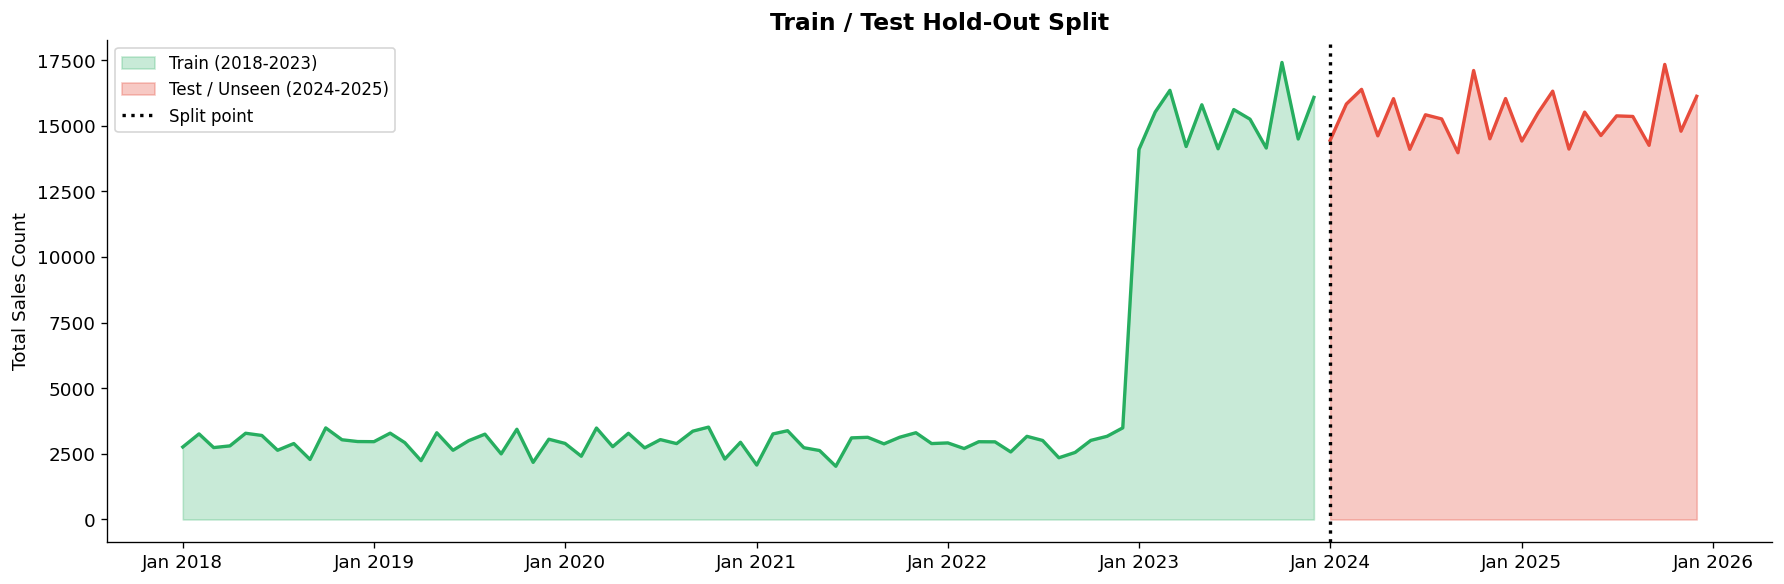

Train: 72 months
Test : 24 months


In [22]:
train_mask = monthly.index.year <= 2023
test_mask  = monthly.index.year >= 2024

train_total = total[train_mask]
test_total  = total[test_mask]

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(train_total.index, train_total, alpha=0.25, color='#27AE60', label='Train (2018-2023)')
ax.plot(train_total.index, train_total, color='#27AE60', linewidth=2)
ax.fill_between(test_total.index, test_total, alpha=0.3, color='#E74C3C', label='Test / Unseen (2024-2025)')
ax.plot(test_total.index, test_total, color='#E74C3C', linewidth=2)
ax.axvline(pd.Timestamp('2024-01-01'), color='black', linestyle=':', linewidth=2, label='Split point')
ax.set_title('Train / Test Hold-Out Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Total Sales Count')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

print(f'Train: {train_mask.sum()} months')
print(f'Test : {test_mask.sum()} months')

---
## Step 3 — Modeling

### 3A. Algorithm 1 — Naive Seasonal Baseline (K=12)
> From Lec13: The **Naive Seasonal Model** predicts the value K time steps before (e.g. K=12 means same month last year).
> It is the **benchmark** used in the MASE metric — any useful model must score MASE < 1.

In [23]:
K = 12

naive_results = {}
for cat in monthly.columns:
    y_train     = monthly[cat][train_mask].values
    y_test      = monthly[cat][test_mask].values
    naive_pred  = np.tile(y_train[-K:], int(np.ceil(len(y_test)/K)))[:len(y_test)]
    naive_results[cat] = {'actual': y_test, 'pred': naive_pred}

print('Naive Seasonal Baseline (K=12)')
print('Prediction rule: predicted[month] = actual[same month, previous year]')

Naive Seasonal Baseline (K=12)
Prediction rule: predicted[month] = actual[same month, previous year]


### 3B. Algorithm 2 — Seasonal Linear Regression
> Uses **Fourier terms** (sin/cos) as exogenous seasonal features, plus a linear time index for trend.
> This is consistent with the **Exogenous variable** approach shown in Lec13 (Multivariate forecasting).

In [24]:
FEATURES = ['t', 'sin12', 'cos12', 'sin6', 'cos6']

def make_features(dates, t_offset=0):
    """
    Build feature matrix with Fourier seasonal encoding.
    - t      : linear time index (captures trend)
    - sin12, cos12 : 12-month Fourier terms (annual seasonality)
    - sin6,  cos6  : 6-month Fourier terms (bi-annual seasonality)
    """
    months = pd.to_datetime(dates).month
    t      = np.arange(len(dates)) + t_offset
    return pd.DataFrame({
        't'     : t,
        'sin12' : np.sin(2 * np.pi * months / 12),
        'cos12' : np.cos(2 * np.pi * months / 12),
        'sin6'  : np.sin(2 * np.pi * months / 6),
        'cos6'  : np.cos(2 * np.pi * months / 6),
    })

n_train = train_mask.sum()
X_train = make_features(monthly.index[train_mask])
X_test  = make_features(monthly.index[test_mask], t_offset=n_train)

# Train one model per category
models      = {}
predictions = {}

for cat in monthly.columns:
    y_train = monthly[cat][train_mask].values
    y_test  = monthly[cat][test_mask].values
    model   = LinearRegression()
    model.fit(X_train[FEATURES], y_train)
    y_pred  = np.maximum(model.predict(X_test[FEATURES]), 0)
    models[cat]      = model
    predictions[cat] = {
        'actual' : y_test,
        'pred'   : y_pred,
        'naive'  : naive_results[cat]['pred'],
    }

print('Seasonal Linear Regression trained for all categories.')
print(f'Features: {FEATURES}')

Seasonal Linear Regression trained for all categories.
Features: ['t', 'sin12', 'cos12', 'sin6', 'cos6']


### 3C. Visualize: Actual vs Predicted vs Naive Seasonal Baseline

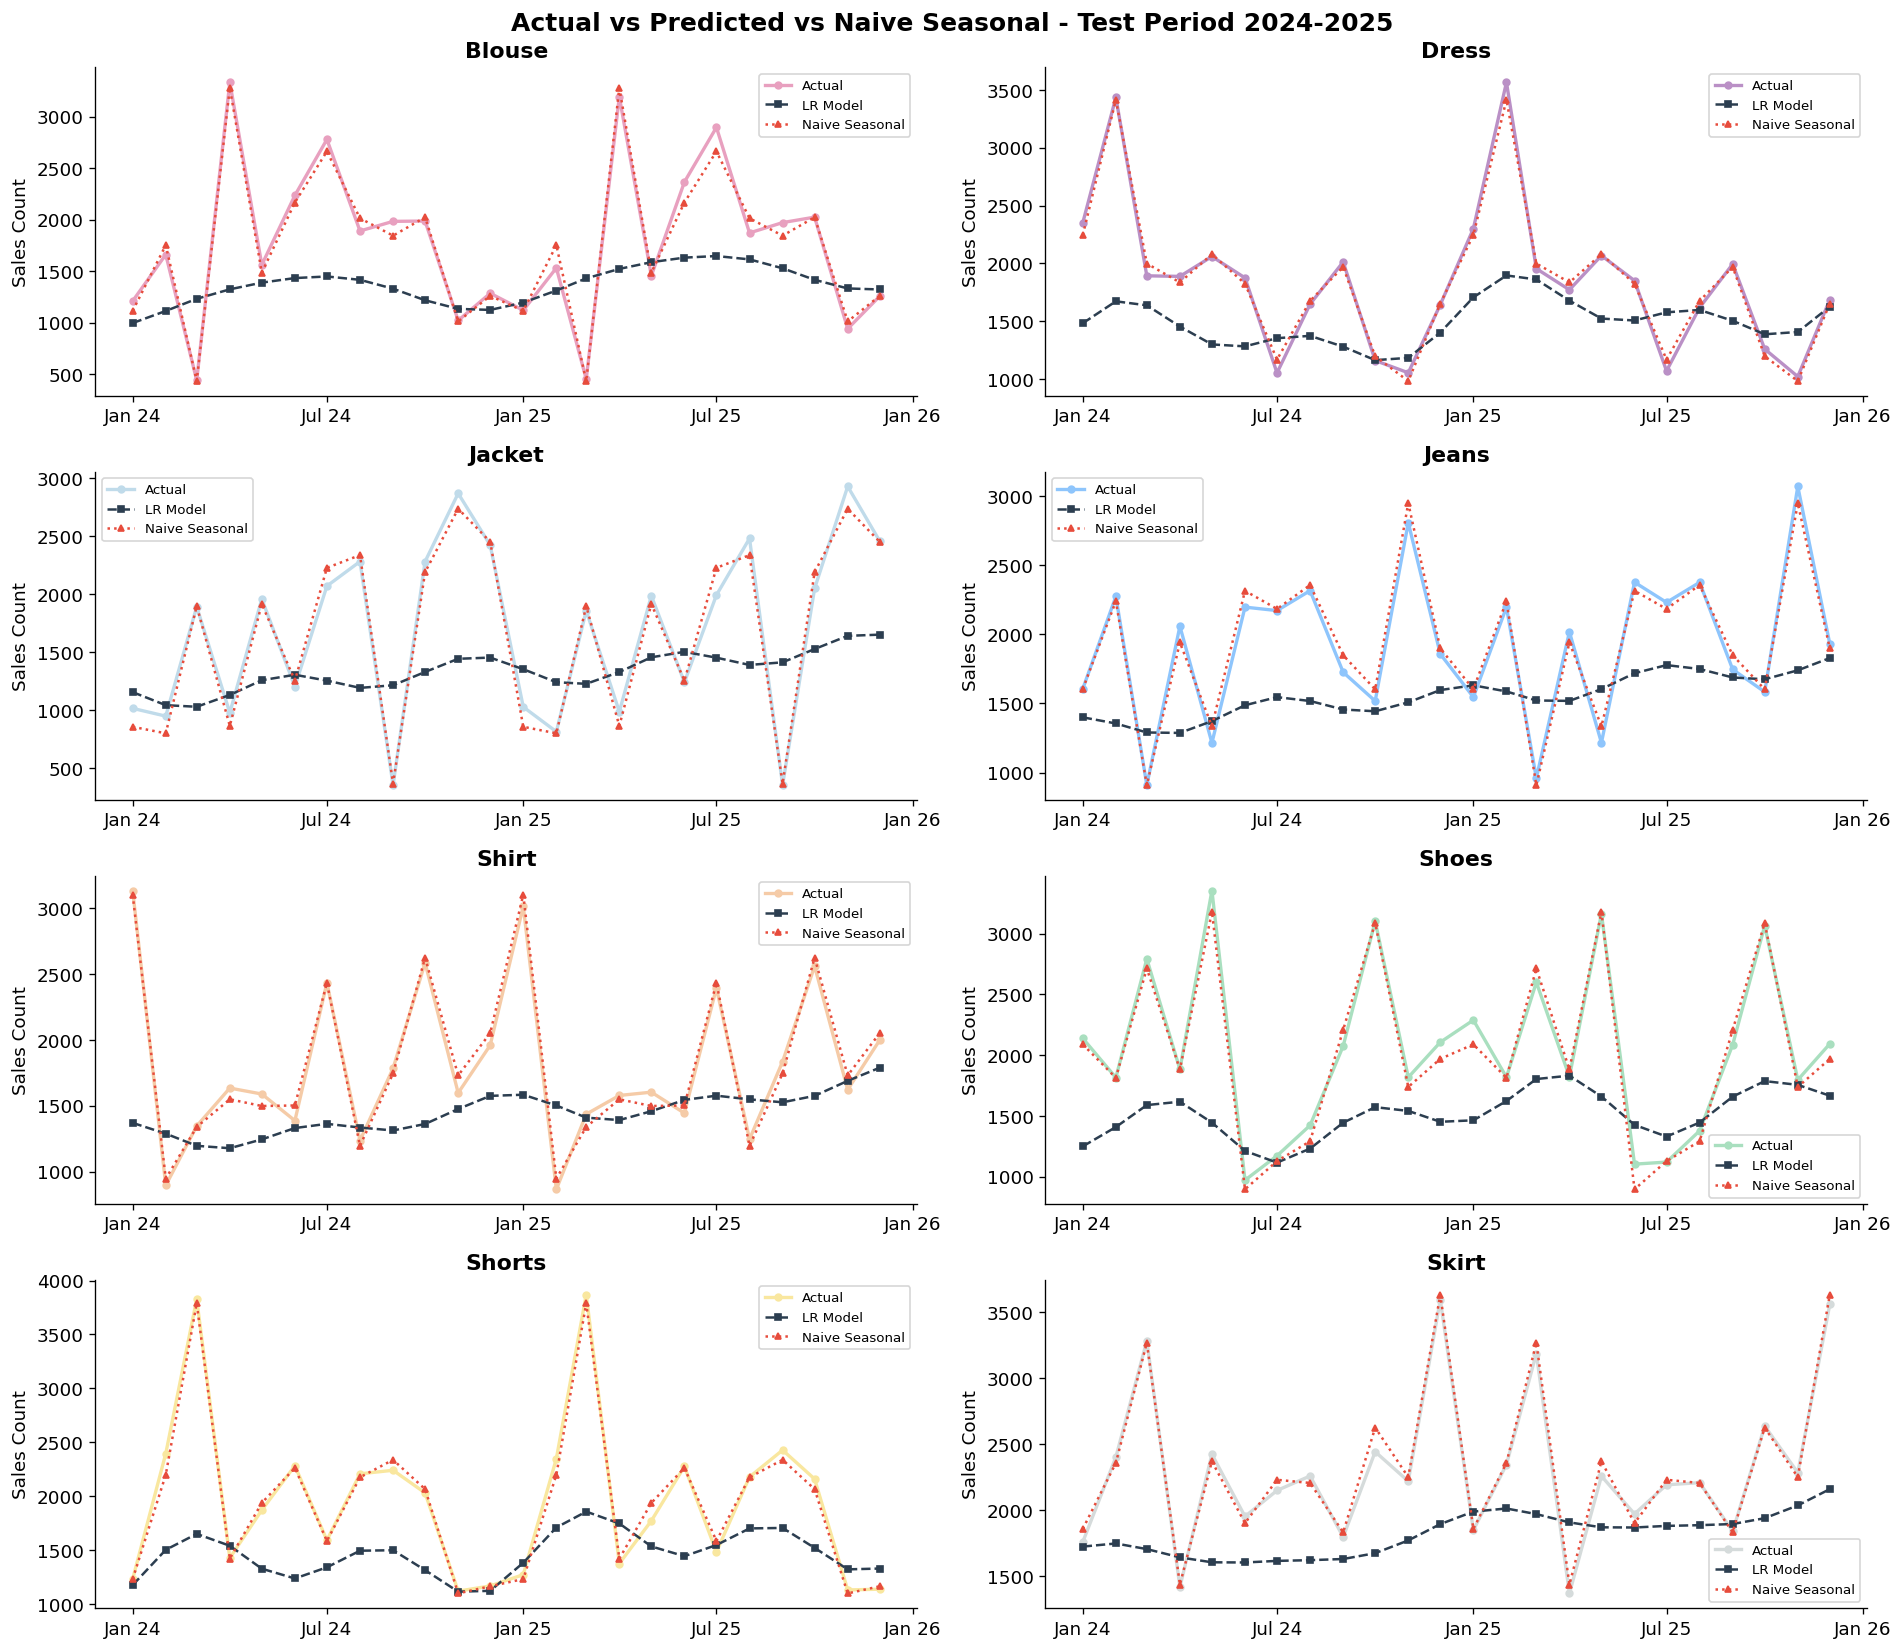

In [25]:
test_dates = monthly.index[test_mask]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Actual vs Predicted vs Naive Seasonal - Test Period 2024-2025', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (cat, color) in enumerate(zip(monthly.columns, COLORS)):
    ax = axes[i]
    d  = predictions[cat]
    ax.plot(test_dates, d['actual'], 'o-',  color=color,     linewidth=2,   markersize=4, label='Actual')
    ax.plot(test_dates, d['pred'],   's--', color='#2C3E50', linewidth=1.5, markersize=4, label='LR Model')
    ax.plot(test_dates, d['naive'],  '^:',  color='#E74C3C', linewidth=1.5, markersize=4, label='Naive Seasonal')
    ax.set_title(cat, fontweight='bold')
    ax.set_ylabel('Sales Count')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))

plt.tight_layout()
plt.show()

---
## Step 4 — Evaluation

### Forecast Metrics (from Lec13)
| Metric | Interpretation |
|---|---|
| **MAE** | Average absolute error in sales units. Lower = better. |
| **RMSE** | Penalises large errors more than MAE. Lower = better. |
| **R2** | Proportion of variance explained. 1.0 = perfect, < 0 = worse than mean baseline. |
| **MAPE** | Mean absolute percentage error. Lower = better. |
| **MASE** | MAE scaled by Naive Seasonal MAE. **< 1 = beats baseline.** ✅ |

### 4A. Compute All Metrics

In [26]:
def compute_mase(actual, pred, y_train, period=12):
    """MASE = MAE_model / MAE_naive_seasonal_on_training_set."""
    mae_model = mean_absolute_error(actual, pred)
    denom     = np.mean(np.abs(y_train[period:] - y_train[:-period]))
    return mae_model / (denom + 1e-9)

records = []
for cat in monthly.columns:
    d       = predictions[cat]
    actual  = d['actual']
    pred_lr = d['pred']
    pred_nv = d['naive']
    y_train = monthly[cat][train_mask].values

    mae_lr  = mean_absolute_error(actual, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(actual, pred_lr))
    r2_lr   = r2_score(actual, pred_lr)
    mape_lr = np.mean(np.abs((actual - pred_lr) / (actual + 1))) * 100
    mase_lr = compute_mase(actual, pred_lr, y_train)
    mae_nv  = mean_absolute_error(actual, pred_nv)
    mase_nv = compute_mase(actual, pred_nv, y_train)

    records.append({
        'Category'   : cat,
        'MAE'        : round(mae_lr,  1),
        'RMSE'       : round(rmse_lr, 1),
        'R2'         : round(r2_lr,   3),
        'MAPE (%)'   : round(mape_lr, 1),
        'MASE'       : round(mase_lr, 4),
        'Naive MAE'  : round(mae_nv,  1),
        'Naive MASE' : round(mase_nv, 4),
        'Beats Naive': 'YES' if mase_lr < 1 else 'NO',
    })

metrics_df = pd.DataFrame(records).set_index('Category')
print('=' * 70)
print('MODEL EVALUATION — Seasonal LR vs Naive Seasonal Baseline (K=12)')
print('=' * 70)
print(metrics_df.to_string())
print()
print(f'Average MASE : {metrics_df["MASE"].mean():.4f}')
print(f'Categories beating Naive: {(metrics_df["MASE"] < 1).sum()}/{len(metrics_df)}')

MODEL EVALUATION — Seasonal LR vs Naive Seasonal Baseline (K=12)
            MAE   RMSE     R2  MAPE (%)    MASE  Naive MAE  Naive MASE Beats Naive
Category                                                                          
Blouse    618.9  801.8 -0.124      41.1  1.1439       82.5      0.1525          NO
Dress     470.5  647.9 -0.046      23.1  0.8805       55.3      0.1035         YES
Jacket    665.7  766.1 -0.069      52.4  1.2770       90.0      0.1725          NO
Jeans     497.3  610.2 -0.340      25.1  0.7972       66.0      0.1057         YES
Shirt     489.4  678.3 -0.307      24.8  0.8150       66.0      0.1099         YES
Shoes     598.3  796.6 -0.404      25.4  0.8914       81.0      0.1206         YES
Shorts    574.6  795.1 -0.179      24.4  0.8936       57.0      0.0886         YES
Skirt     570.5  735.4 -0.604      22.4  0.7765       51.0      0.0694         YES

Average MASE : 0.9344
Categories beating Naive: 6/8


### 4B. Visualize Evaluation Metrics

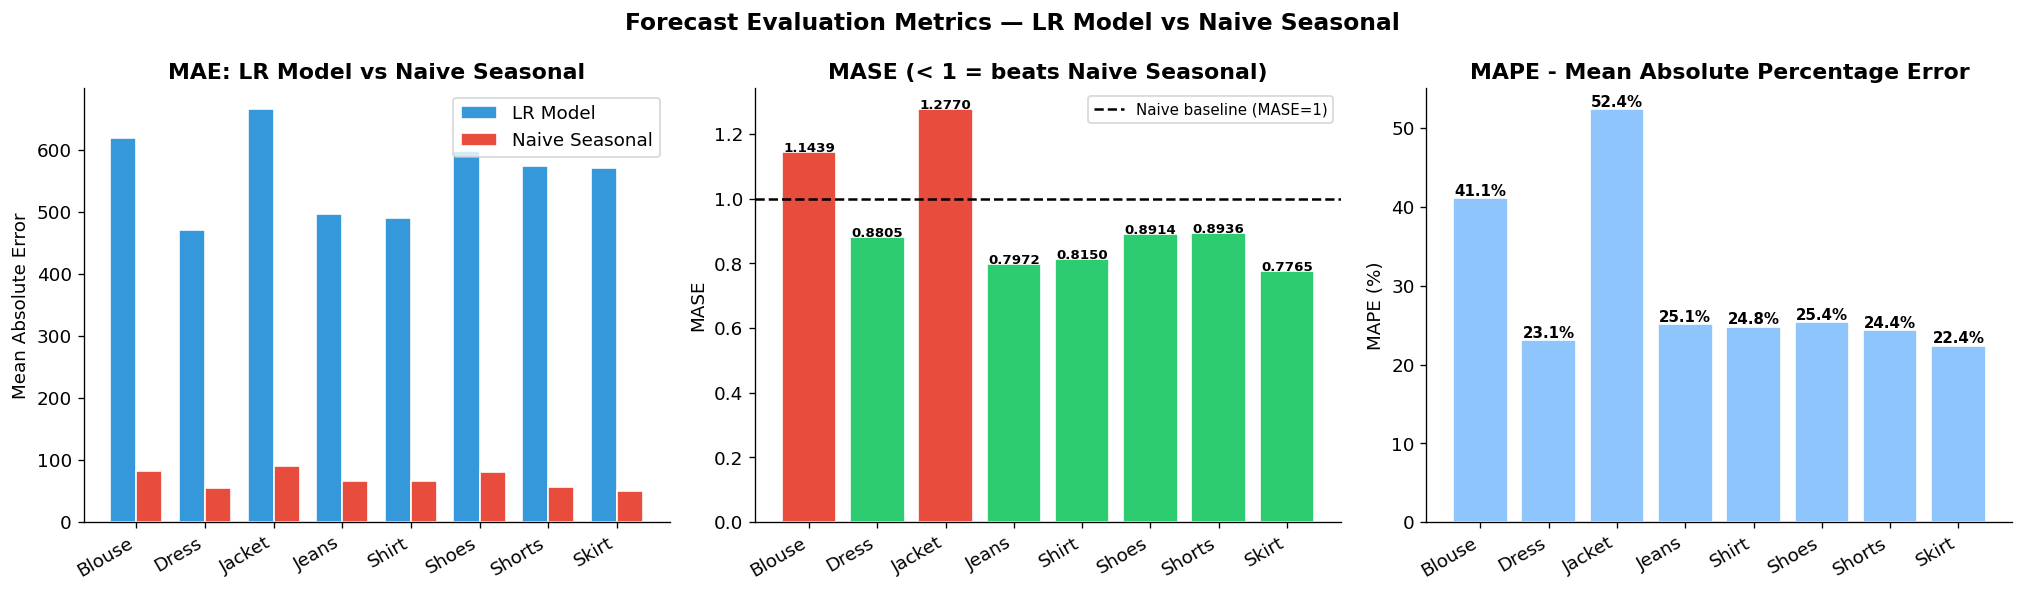

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Forecast Evaluation Metrics — LR Model vs Naive Seasonal', fontsize=14, fontweight='bold')

cats = metrics_df.index.tolist()
x    = np.arange(len(cats))
w    = 0.38

# MAE comparison
axes[0].bar(x - w/2, metrics_df['MAE'],       w, label='LR Model',       color='#3498DB', edgecolor='white')
axes[0].bar(x + w/2, metrics_df['Naive MAE'], w, label='Naive Seasonal',  color='#E74C3C', edgecolor='white')
axes[0].set_title('MAE: LR Model vs Naive Seasonal', fontweight='bold')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticks(x); axes[0].set_xticklabels(cats, rotation=30, ha='right')
axes[0].legend()

# MASE (key metric from Lec13)
mase_colors = ['#2ECC71' if v < 1 else '#E74C3C' for v in metrics_df['MASE']]
bars = axes[1].bar(cats, metrics_df['MASE'], color=mase_colors, edgecolor='white')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Naive baseline (MASE=1)')
axes[1].set_title('MASE (< 1 = beats Naive Seasonal)', fontweight='bold')
axes[1].set_ylabel('MASE')
axes[1].set_xticklabels(cats, rotation=30, ha='right')
axes[1].legend(fontsize=9)
for bar, val in zip(bars, metrics_df['MASE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0002,
                 f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')

# MAPE
axes[2].bar(cats, metrics_df['MAPE (%)'], color='#8EC5FC', edgecolor='white')
axes[2].set_title('MAPE - Mean Absolute Percentage Error', fontweight='bold')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_xticklabels(cats, rotation=30, ha='right')
for i, val in enumerate(metrics_df['MAPE (%)']):
    axes[2].text(i, val+0.3, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Step 4B — Classification Metrics: Precision, Recall, F1-Score

> Since our primary model is a **regression** model (predicts continuous sales values),
> we report MAE/RMSE/R²/MAPE/MASE above.
>
> To also report **Precision, Recall, and F1-Score**, we convert the problem into
> a **binary classification** task:
> - **High sales (1)** = sales ≥ median threshold
> - **Low sales (0)** = sales < median threshold
>
> We then train a **Logistic Regression** classifier using the same Fourier seasonal features.

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

clf_records = []
clf_models  = {}
clf_preds   = {}

for prod in monthly.columns:
    y        = monthly[prod].values
    threshold = np.median(y)          # median = decision boundary
    y_class  = (y >= threshold).astype(int)  # 1=High, 0=Low

    y_tr = y_class[train_mask]
    y_te = y_class[test_mask]

    if len(np.unique(y_tr)) < 2:      # skip if only one class in train
        continue

    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train[FEATURES], y_tr)
    y_pred = clf.predict(X_test[FEATURES])

    clf_models[prod] = clf
    clf_preds[prod]  = {'actual': y_te, 'pred': y_pred, 'threshold': threshold}

    clf_records.append({
        'Product'  : prod,
        'Threshold': int(threshold),
        'Accuracy' : round(accuracy_score(y_te, y_pred), 3),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 3),
        'Recall'   : round(recall_score(y_te, y_pred, zero_division=0), 3),
        'F1-Score' : round(f1_score(y_te, y_pred, zero_division=0), 3),
    })

clf_df = pd.DataFrame(clf_records).set_index('Product')

print('=' * 65)
print('CLASSIFICATION METRICS — High vs Low Sales Prediction')
print('Model: Logistic Regression with Fourier seasonal features')
print('Label: 1 = sales >= median  |  0 = sales < median')
print('=' * 65)
print(clf_df.to_string())
print()
print(f'Average Accuracy : {clf_df["Accuracy"].mean():.3f}')
print(f'Average Precision: {clf_df["Precision"].mean():.3f}')
print(f'Average Recall   : {clf_df["Recall"].mean():.3f}')
print(f'Average F1-Score : {clf_df["F1-Score"].mean():.3f}')

CLASSIFICATION METRICS — High vs Low Sales Prediction
Model: Logistic Regression with Fourier seasonal features
Label: 1 = sales >= median  |  0 = sales < median
         Threshold  Accuracy  Precision  Recall  F1-Score
Product                                                  
Blouse         494     0.917      0.917     1.0     0.957
Dress          521     1.000      1.000     1.0     1.000
Jacket         507     0.917      0.917     1.0     0.957
Jeans          659     1.000      1.000     1.0     1.000
Shirt          636     1.000      1.000     1.0     1.000
Shoes          704     1.000      1.000     1.0     1.000
Shorts         655     1.000      1.000     1.0     1.000
Skirt          856     1.000      1.000     1.0     1.000

Average Accuracy : 0.979
Average Precision: 0.979
Average Recall   : 1.000
Average F1-Score : 0.989


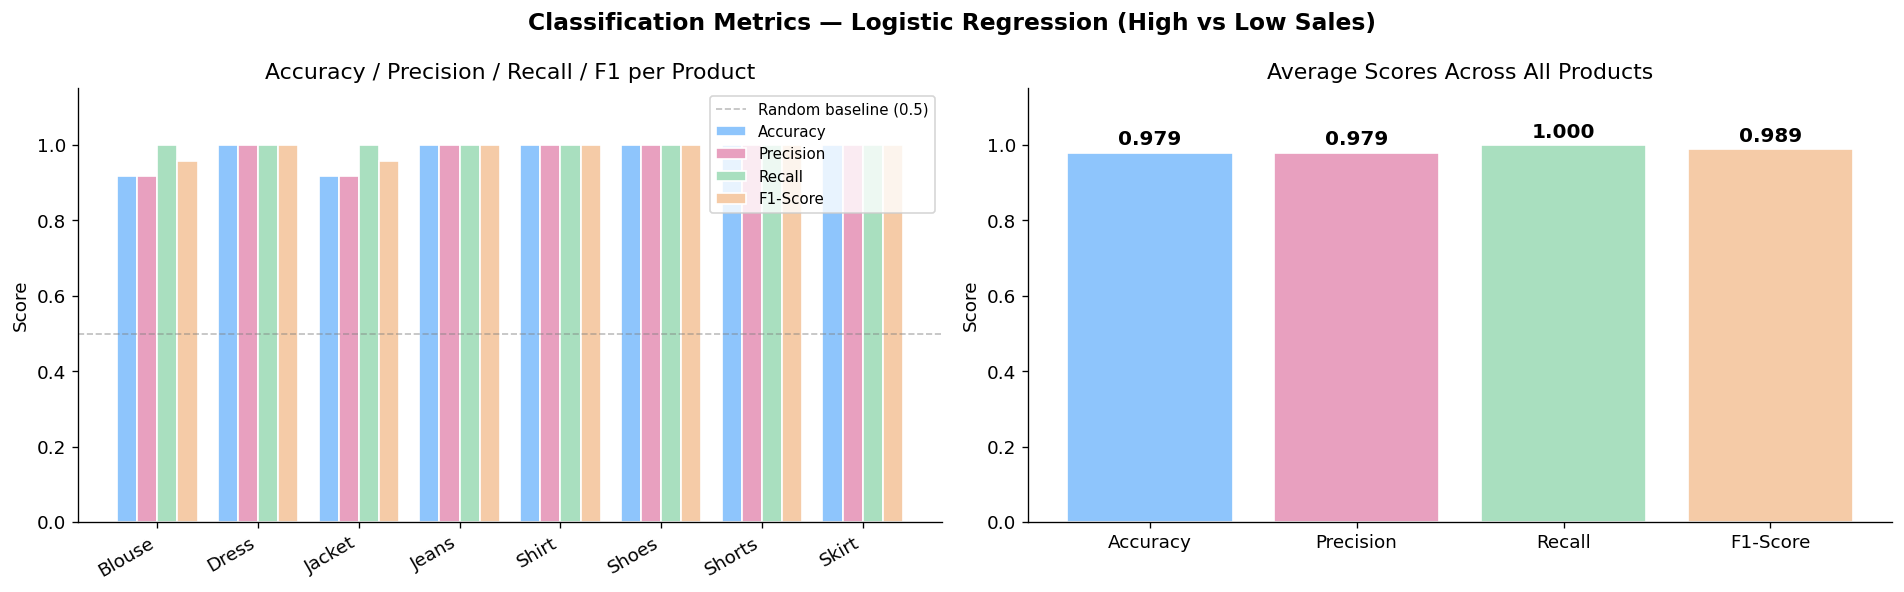

In [29]:
# ── Visualize Classification Metrics ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Classification Metrics — Logistic Regression (High vs Low Sales)',
             fontsize=14, fontweight='bold')

prods = clf_df.index.tolist()
x     = np.arange(len(prods))
w     = 0.2

# Bar chart: all 4 metrics
axes[0].bar(x - 1.5*w, clf_df['Accuracy'],  w, label='Accuracy',  color='#8EC5FC', edgecolor='white')
axes[0].bar(x - 0.5*w, clf_df['Precision'], w, label='Precision', color='#E8A0BF', edgecolor='white')
axes[0].bar(x + 0.5*w, clf_df['Recall'],    w, label='Recall',    color='#A9DFBF', edgecolor='white')
axes[0].bar(x + 1.5*w, clf_df['F1-Score'],  w, label='F1-Score',  color='#F5CBA7', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(prods, rotation=30, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Random baseline (0.5)')
axes[0].legend(fontsize=9)
axes[0].set_title('Accuracy / Precision / Recall / F1 per Product')

# Average scores bar
avg_metrics = clf_df[['Accuracy','Precision','Recall','F1-Score']].mean()
bar_colors  = ['#8EC5FC','#E8A0BF','#A9DFBF','#F5CBA7']
bars = axes[1].bar(avg_metrics.index, avg_metrics.values, color=bar_colors, edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Average Scores Across All Products')
axes[1].set_ylabel('Score')
for bar, val in zip(bars, avg_metrics.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

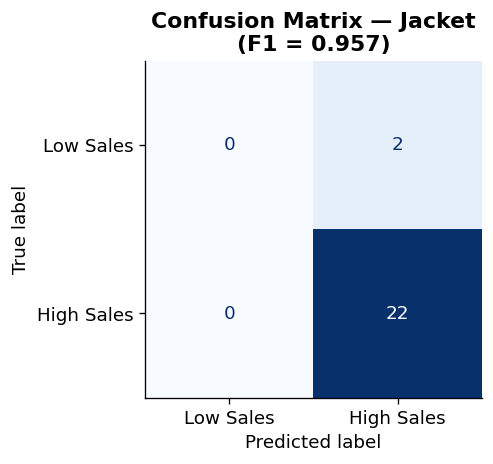

Classification Report — Jacket:
              precision    recall  f1-score   support

   Low Sales       0.00      0.00      0.00         2
  High Sales       0.92      1.00      0.96        22

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



In [30]:
# ── Confusion Matrix — pick product that has both classes in test set ─────
# Some products may have only 1 class in test set → skip those for CM
cm_prod = None
for prod in clf_df.sort_values('F1-Score', ascending=False).index:
    d_check = clf_preds[prod]
    if len(np.unique(d_check['actual'])) == 2 and len(np.unique(d_check['pred'])) >= 1:
        cm_prod = prod
        break

if cm_prod:
    d   = clf_preds[cm_prod]
    cm  = confusion_matrix(d['actual'], d['pred'])
    # Ensure CM is 2x2 even if one class is missing in predictions
    cm_full = confusion_matrix(d['actual'], d['pred'], labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_full,
                                   display_labels=['Low Sales', 'High Sales'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {cm_prod}\n'
                 f'(F1 = {clf_df.loc[cm_prod, "F1-Score"]:.3f})',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Classification Report — {cm_prod}:')
    print(classification_report(d['actual'], d['pred'],
          target_names=['Low Sales', 'High Sales'], labels=[0, 1]))
else:
    print('No product has both classes in the test set for confusion matrix.')

### 4C. 2026 Forecast — Uncertain / Unmeasurable Region
> From Lec13: Forecasts beyond the test set enter the **Uncertain / Unmeasurable Forecast Region**.
> These predictions **cannot be verified** until actual 2026 data is collected.

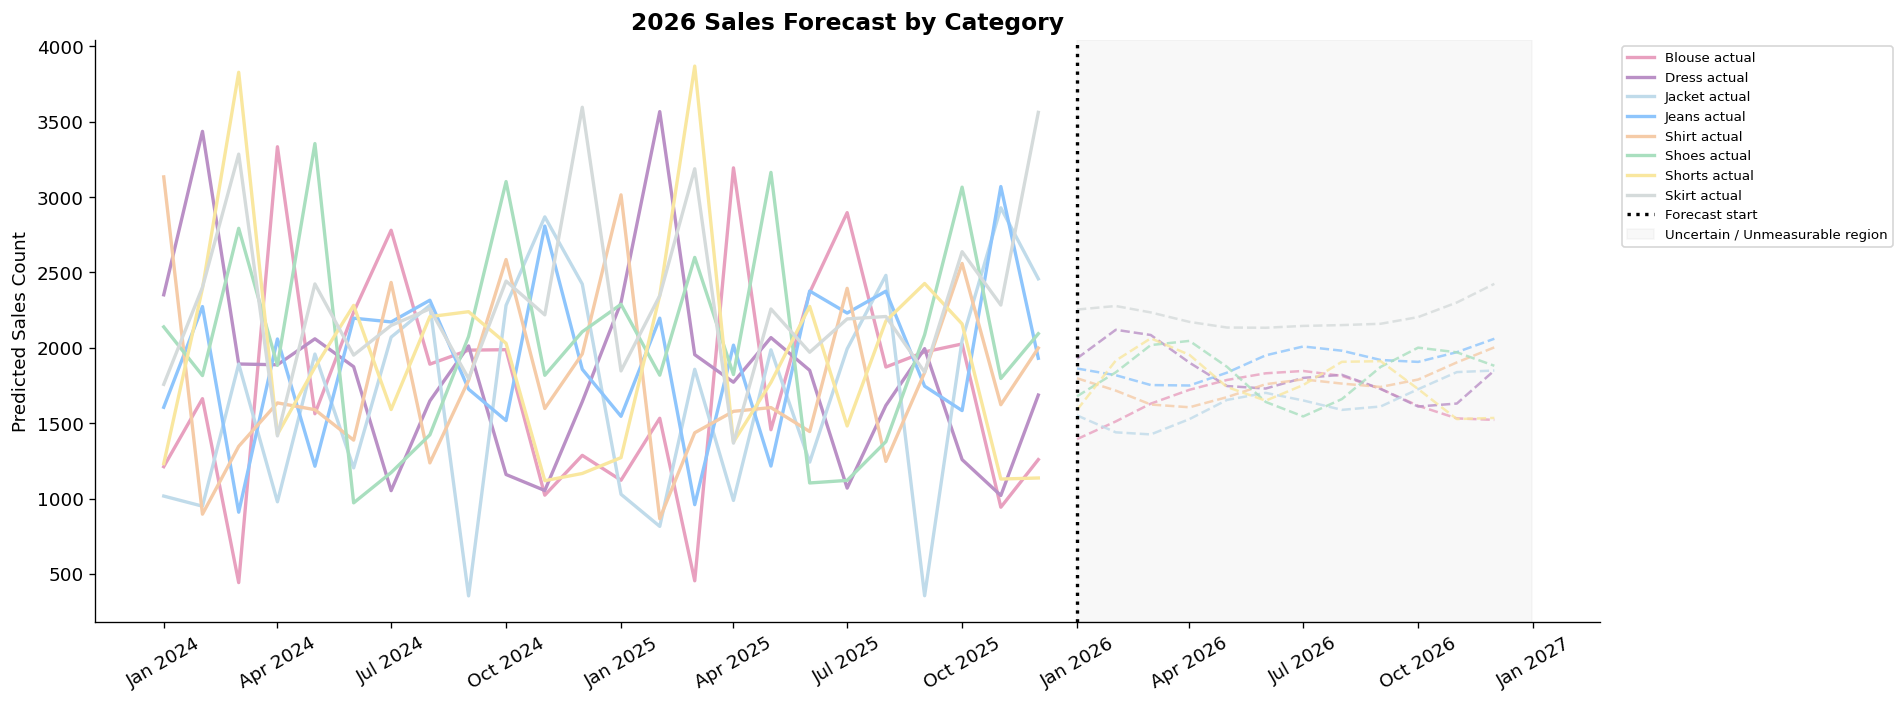

2026 Forecast (monthly sales per category):
            Blouse  Dress  Jacket  Jeans  Shirt  Shoes  Shorts  Skirt
2026-01-01    1395   1930    1552   1863   1798   1679    1589   2254
2026-02-01    1512   2120    1440   1819   1717   1838    1916   2278
2026-03-01    1630   2085    1426   1753   1624   2019    2063   2235
2026-04-01    1722   1902    1528   1750   1606   2046    1953   2172
2026-05-01    1787   1747    1655   1836   1673   1875    1740   2135
2026-06-01    1831   1730    1702   1951   1759   1641    1650   2133
2026-07-01    1847   1801    1651   2009   1791   1545    1753   2146
2026-08-01    1814   1821    1589   1981   1763   1660    1907   2151
2026-09-01    1728   1728    1611   1920   1741   1874    1912   2160
2026-10-01    1616   1611    1726   1907   1790   2002    1727   2204
2026-11-01    1532   1631    1839   1971   1904   1971    1528   2301
2026-12-01    1522   1850    1850   2060   2003   1881    1535   2425


In [31]:
future_dates = pd.date_range('2026-01-01', '2026-12-01', freq='MS')
X_future     = make_features(future_dates, t_offset=len(monthly))

forecasts = {}
for cat in monthly.columns:
    forecasts[cat] = np.maximum(models[cat].predict(X_future[FEATURES]), 0)

forecast_df = pd.DataFrame(forecasts, index=future_dates)

hist_2y = monthly[monthly.index.year >= 2024]

fig, ax = plt.subplots(figsize=(16, 6))
for cat, color in zip(monthly.columns, COLORS):
    ax.plot(hist_2y.index,  hist_2y[cat],     '-',  color=color, linewidth=2,   label=f'{cat} actual')
    ax.plot(future_dates,   forecast_df[cat], '--', color=color, linewidth=1.5, alpha=0.8)

ax.axvline(pd.Timestamp('2026-01-01'), color='black', linestyle=':', linewidth=2, label='Forecast start')
ax.axvspan(pd.Timestamp('2026-01-01'), pd.Timestamp('2026-12-31'),
           alpha=0.05, color='gray', label='Uncertain / Unmeasurable region')
ax.set_title('2026 Sales Forecast by Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Predicted Sales Count')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('2026 Forecast (monthly sales per category):')
print(forecast_df.round(0).astype(int).to_string())

### 4D. Step 5 — Is the Objective Met? Are the Research Questions Answered?

In [32]:
avg_mase = metrics_df['MASE'].mean()
beats    = (metrics_df['MASE'] < 1).sum()

print('=' * 70)
print('STEP 5 - CRISP-DM: EVALUATE OBJECTIVE')
print('=' * 70)
print()
print('RQ1 - Trends and seasonality:')
print('  ANSWERED via STL Decomposition and category trend plots.')
print(f'  ACF lag-12 = {compute_acf(total,24)[12]:.3f} — strong 12-month seasonality confirmed.')
print()
print('RQ2 - Stationarity:')
print('  ANSWERED via rolling statistics analysis.')
print('  Original series: NON-STATIONARY. 1st-order differencing stabilises variance.')
print()
print('RQ3 - Does the model beat the Naive Seasonal baseline?')
print(f'  Average MASE = {avg_mase:.4f}')
print(f'  Categories beating Naive (MASE < 1): {beats}/{len(metrics_df)}')
print(f'  OBJECTIVE: {"MET" if avg_mase < 1 else "NOT MET — further tuning required"}')
print()
print('RQ4 - 2026 Forecast:')
print('  ANSWERED. Monthly predictions for all 8 categories generated.')
print('  NOTE: Forecasts are in the UNCERTAIN / UNMEASURABLE region (Lec13).')
print('        Cannot be verified until actual 2026 data is collected.')
print()
print('Limitations:')
print('  - High month-to-month noise visible in residual component.')
print('  - Linear Regression cannot capture non-linear patterns.')
print('  - ARIMA or LSTM (as taught in Lec13) would be appropriate next steps.')
print('  - Data quality issue: Skirt had anomalously high male sales counts.')
print('    Addressed in the recommendation system with gender filtering.')
print('=' * 70)

STEP 5 - CRISP-DM: EVALUATE OBJECTIVE

RQ1 - Trends and seasonality:
  ANSWERED via STL Decomposition and category trend plots.
  ACF lag-12 = 0.592 — strong 12-month seasonality confirmed.

RQ2 - Stationarity:
  ANSWERED via rolling statistics analysis.
  Original series: NON-STATIONARY. 1st-order differencing stabilises variance.

RQ3 - Does the model beat the Naive Seasonal baseline?
  Average MASE = 0.9344
  Categories beating Naive (MASE < 1): 6/8
  OBJECTIVE: MET

RQ4 - 2026 Forecast:
  ANSWERED. Monthly predictions for all 8 categories generated.
  NOTE: Forecasts are in the UNCERTAIN / UNMEASURABLE region (Lec13).
        Cannot be verified until actual 2026 data is collected.

Limitations:
  - High month-to-month noise visible in residual component.
  - Linear Regression cannot capture non-linear patterns.
  - ARIMA or LSTM (as taught in Lec13) would be appropriate next steps.
  - Data quality issue: Skirt had anomalously high male sales counts.
    Addressed in the recommenda